# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown. 

In this case, we are facing a Discontinuous function

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [3]:
#Benchmark1
lowfid = lambda x: (0.5*(6.*x/5.-2.)**2*np.sin(12.*x/5.-4)+10.*(x/5-0.5)-5.)*(x<2.5) + (3+0.5*(6.*x/5.-2)**2*np.sin(12.*x/5.-4)+10*(x/5.-0.5)-5.)*(x>2.5)
highfid = lambda x: (2*lowfid(x)- 20*x/5.+20)*(x/5.<0.5) + (4+2*lowfid(x)- 20*x/5.+20)*(x/5.>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

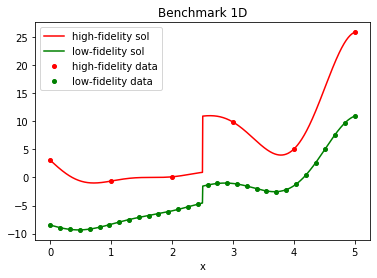

In [4]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

The function training took 23.42850399017334 seconds.


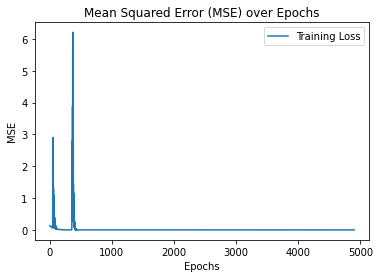

Test MSE: 82.23769850932104
R^2: -0.6790232595573984


In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 6.317893981933594 seconds.


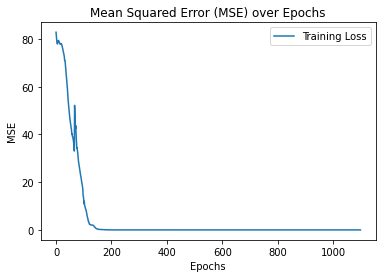

Test MSE: 11.78303544188726
R^2: 0.7594291798806173


In [6]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 22.575026750564575 seconds.


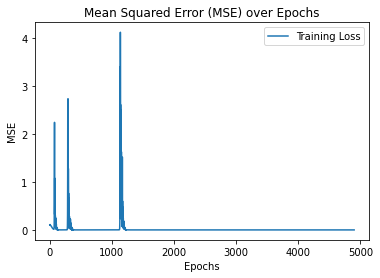

The function training took 5.461296081542969 seconds.


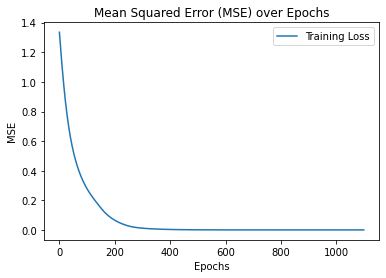

Test MSE: 6.327758306546256
R^2: 0.8708079923182128


In [7]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

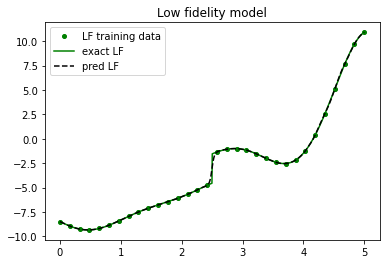

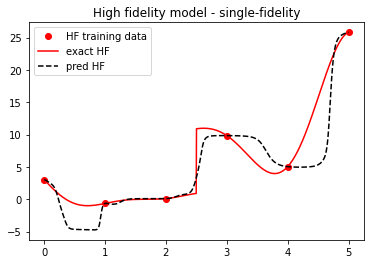

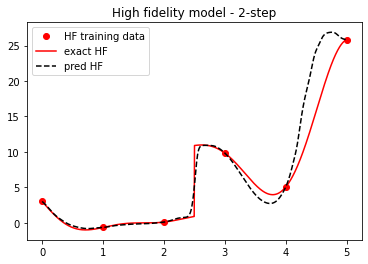

In [8]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [9]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.4,0.45])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1 
sigma=0.1  
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =10000
burnin = 3000
n_chains=2

# Multifidelity

real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.08: 100%|██████████| 10000/10000 [23:53<00:00,  6.98it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 10000/10000 [25:33<00:00,  6.52it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [1.874 1.964 2.573 3.739]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.874  0.220   1.404    2.234      0.022    0.016     113.0     138.0   
x1  1.964  0.234   1.514    2.368      0.022    0.016     118.0     272.0   
x2  2.573  1.192   0.977    3.788      0.828    0.708       3.0      90.0   
x3  3.739  0.029   3.688    3.793      0.001    0.001    1244.0    1496.0   

    r_hat  
x0   1.04  
x1   1.02  
x2   1.84  
x3   1.00  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...


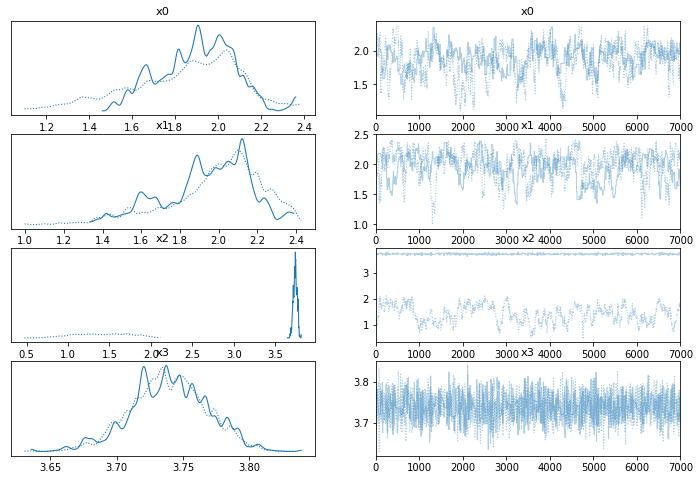

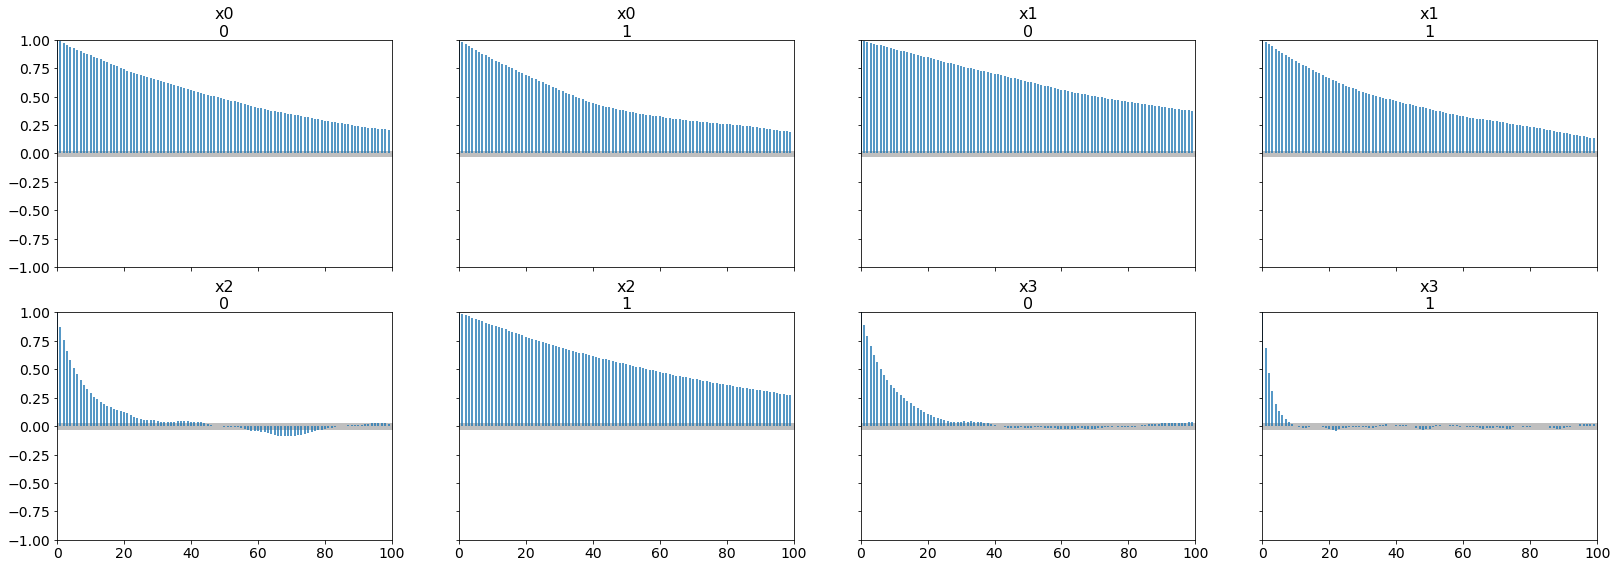

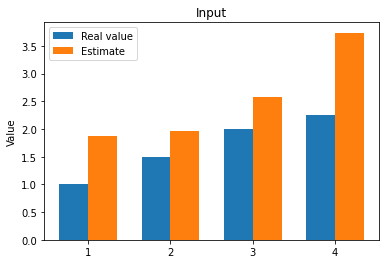

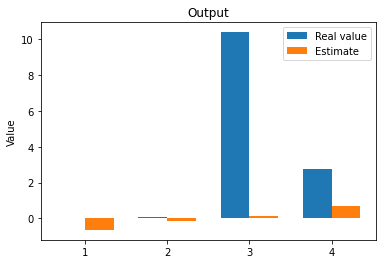

The function inverse took 2980.8234214782715 seconds.


In [10]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

In [11]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=lowfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.09:  36%|███▋      | 3649/10000 [05:32<08:28, 12.48it/s]  